# 常见分布与建模假设

## Goal
同样的平均数可以来自不同支持和机制。本Notebook从已知合成分布生成数据，检查均值、经验方差、类别频率和直方图，再用混合Poisson挑战错误假设。先修第十九讲；理论推导在lecture.pdf，独立实验说明在lab.pdf。

保留输出的一次运行：Bernoulli均值0.2500833，二项均值1.992，Poisson均值3.99225，Gaussian均值1.0092375；混合Poisson经验方差12.98137，远离同均值单Poisson约4的理论方差。这些是有限模拟，不是现实数据的检验结论。

## Setup
在本单元目录启动，使用environment.yml。NumPy负责PCG64随机生成和数组；Matplotlib仅绘图。所有检查使用显式异常，不依赖assert。当前目录只用于导入本单元模块，不使用个人文件或网络。

In [1]:
from pathlib import Path
import sys, json, math, io
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image
import experiment as e
plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white"})
print({"Python": sys.version.split()[0], "NumPy": np.__version__,
       "Matplotlib": matplotlib.__version__, "generator": "PCG64"})
def show_figure(fig):
    fig.tight_layout(pad=1.5)
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=130, bbox_inches="tight")
    plt.close(fig)
    display(Image(data=buffer.getvalue()))

{'Python': '3.12.14', 'NumPy': '2.3.5', 'Matplotlib': '3.10.8', 'generator': 'PCG64'}


### Key Assumptions
一行对应一个完整独立生成的观测；二项中的8次试验是同概率独立的假设；计数窗口暴露量相同。Gaussian第二个参数是方差4，生成时传标准差2。Categorical编码0/1/2只是标签。混合组等概率选强度1或7，给定组后生成Poisson。不同列不是一个真实系统的联合观测，不从列间样本相关性推断机制。

In [2]:
print("Main seeds:", e.SEEDS)
print("Mixture component seeds:", e.SEEDS["mixture"] + 100, e.SEEDS["mixture"] + 200)
print("Repeat seed = 202000 + 100 * size + repeat, repeat = 0..39")
data = e.generate_data()
print("Records per model:", len(data["poisson"]))
print("First five Poisson counts:", data["poisson"][:5].tolist())

Main seeds: {'bernoulli': 20001, 'binomial': 20002, 'categorical': 20003, 'poisson': 20004, 'gaussian': 20005, 'mixture': 20006}
Mixture component seeds: 20106 20206
Repeat seed = 202000 + 100 * size + repeat, repeat = 0..39
Records per model: 12000
First five Poisson counts: [2, 3, 5, 3, 5]


## Steps
### 1. 支持范围和数学边界
整数支持外的查询返回0；类型不对或参数非法抛异常。n=0、p为0或1、λ=0是合法边界。

In [3]:
print({"n=0": e.binomial_pmf(0, 0, .25),
       "p=1": e.binomial_pmf(8, 8, 1),
       "lambda=0": e.poisson_pmf(0, 0),
       "outside_support": e.binomial_pmf(9, 8, .25)})
for label, call in [("fractional n", lambda: e.binomial_pmf(1, 8.5, .25)),
                    ("boolean p", lambda: e.bernoulli_pmf(1, True)),
                    ("zero variance", lambda: e.normal_pdf(0, 0, 0))]:
    try:
        call()
    except ValueError as error:
        print(label, "->", type(error).__name__, str(error))
    else:
        raise ValueError("Expected an explicit rejection")

{'n=0': 1.0, 'p=1': 1.0, 'lambda=0': 1.0, 'outside_support': 0.0}
fractional n -> ValueError n must be an integer scalar
boolean p -> ValueError p must be a real scalar, not bool/text/complex/array
zero variance -> ValueError variance must be strictly positive


### 2. 样本矩与理论矩
经验方差分母为n。下表只是整齐的文本输出，不使用未说明的库默认ddof。每个模型的全部12000条都参与计算。

In [4]:
theory = {"bernoulli": (.25, .1875), "binomial": (2, 1.5),
          "poisson": (4, 4), "gaussian": (1, 4), "mixture": (4, 13)}
print("family       empirical mean  theory mean  empirical variance  theory variance")
for family, target in theory.items():
    stats = e.moments(data[family])
    print(f"{family:12} {stats['mean']:14.8f} {target[0]:12.6f}"
          f" {stats['variance_n']:19.8f} {target[1]:16.6f}")

family       empirical mean  theory mean  empirical variance  theory variance
bernoulli        0.25008333     0.250000          0.18754166         0.187500
binomial         1.99200000     2.000000          1.48310267         1.500000


poisson          3.99225000     4.000000          3.93252327         4.000000


gaussian         1.00923751     1.000000          3.91344806         4.000000
mixture          3.95858333     4.000000         12.98136799        13.000000


### 3. Categorical概率不是编号的大小
每类频率与每类指标方差有固定解释。改编号会改编号均值；不改变各类别事件的概率。

In [5]:
counts = np.bincount(data["categorical"], minlength=3)
freq = counts / len(data["categorical"])
print("A/B/C counts:", counts.tolist())
print("A/B/C frequencies:", freq.tolist())
print("Indicator variances:", [e.moments((data["categorical"] == j).astype(int))["variance_n"] for j in range(3)])
print("Exact coded means: 0/1/2 ->", .3 + 2 * .2,
      "; 0/10/100 ->", 10 * .3 + 100 * .2)

A/B/C counts: [5986, 3589, 2425]
A/B/C frequencies: [0.49883333333333335, 0.2990833333333333, 0.20208333333333334]


Indicator variances: [0.24999863888888887, 0.20963249305555554, 0.1612456597222222]
Exact coded means: 0/1/2 -> 0.7 ; 0/10/100 -> 23.0


### 4. 离散经验质量
柱高是计数/全部样本量。Poisson图只显示0到18，图外频率另报；没有在窗口内重新归一化。曲线连线帮助读图，非整数点没有质量。

binomial observed fraction outside display: 0.0
poisson observed fraction outside display: 0.0


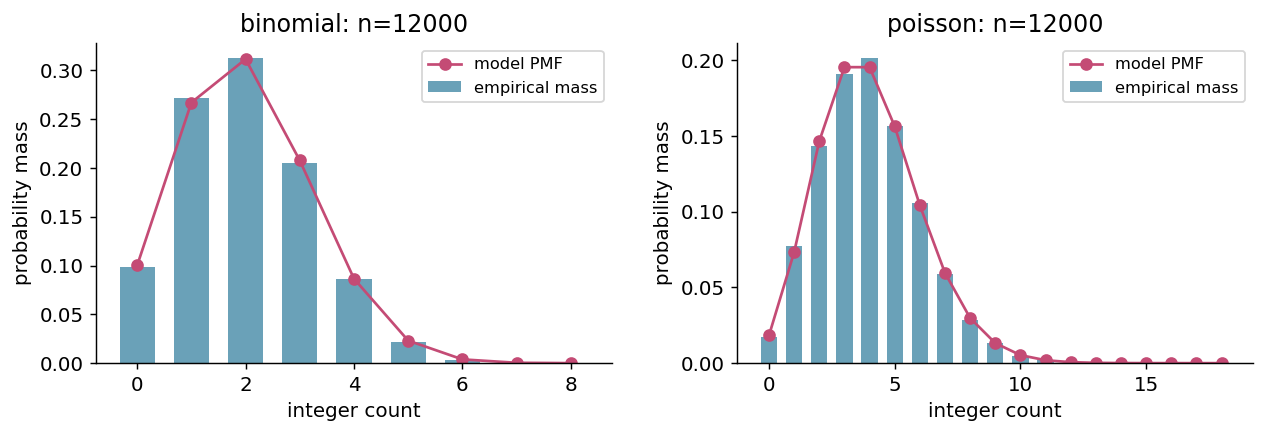

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, family, maximum in zip(axes, ["binomial", "poisson"], [8, 18]):
    xs = np.arange(maximum + 1)
    values = data[family]
    observed = np.bincount(values, minlength=maximum + 1)[:maximum + 1] / len(values)
    expected = ([e.binomial_pmf(int(k), 8, .25) for k in xs] if family == "binomial"
                else [e.poisson_pmf(int(k), 4) for k in xs])
    ax.bar(xs, observed, width=.65, color="#2b7a9b", alpha=.7, label="empirical mass")
    ax.plot(xs, expected, "o-", color="#c44b75", label="model PMF")
    ax.set(xlabel="integer count", ylabel="probability mass", title=f"{family}: n=12000")
    ax.legend(fontsize=9)
    print(family, "observed fraction outside display:", float(np.mean(values > maximum)))
show_figure(fig)

### 5. 连续经验密度
两种箱宽使用同一批Gaussian数据。密度柱面积才是频率；两张图的峰高可不同。理论密度对应均值1、方差4。

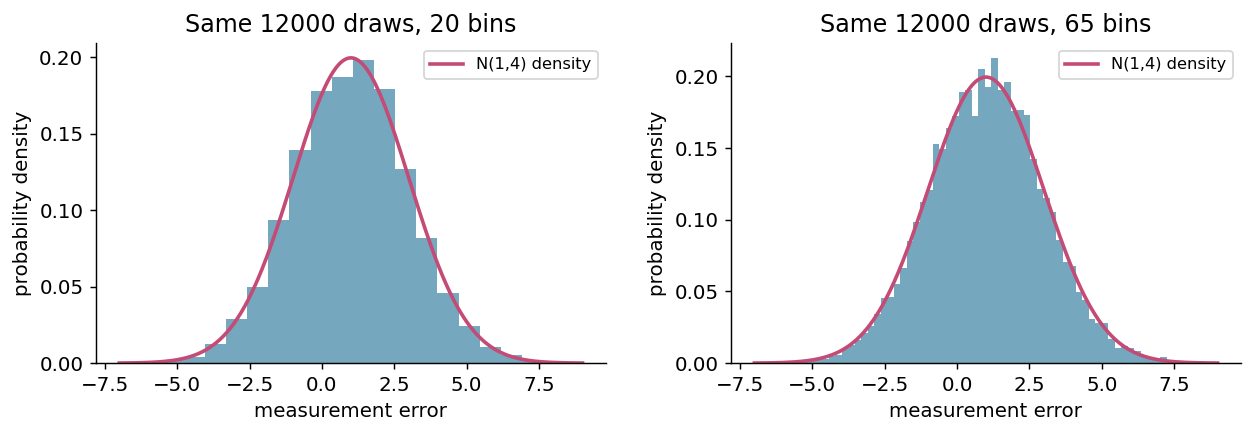

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
xgrid = np.linspace(-7, 9, 401)
density = [e.normal_pdf(float(x), 1, 4) for x in xgrid]
for ax, bins in zip(axes, [20, 65]):
    ax.hist(data["gaussian"], bins=bins, density=True, color="#2b7a9b", alpha=.65)
    ax.plot(xgrid, density, color="#c44b75", lw=2, label="N(1,4) density")
    ax.set(xlabel="measurement error", ylabel="probability density", title=f"Same 12000 draws, {bins} bins")
    ax.legend(fontsize=9)
show_figure(fig)

### 6. 均值接近不能掩盖过度离散
已知合成机制下，混合Poisson理论均值4、方差13。零值质量也明显不同。这里只用明确反例拒绝“均值相同就等价”。

Mixture mean / variance: 3.9585833333333333 12.981367993055555
Observed zero frequency: 0.19041666666666668
Mixture theoretical zero mass: 0.18439566156849843
Poisson(4) theoretical zero mass: 0.01831563888873418


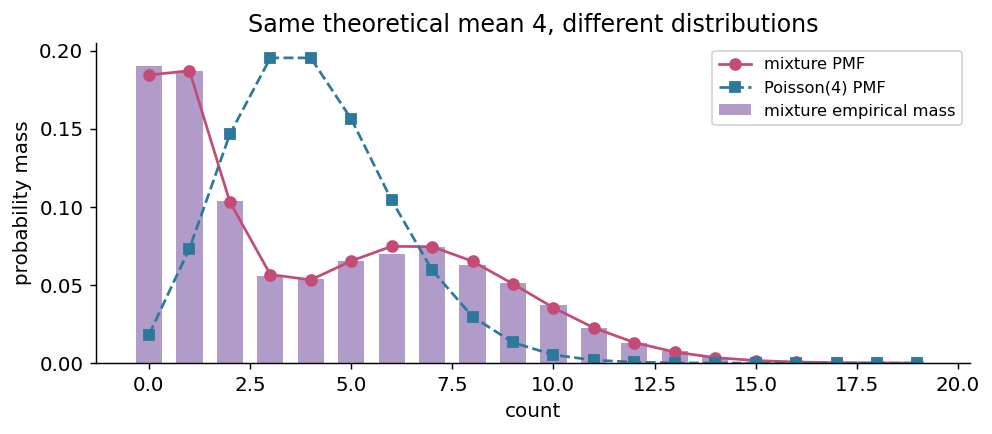

In [8]:
mix_stats = e.moments(data["mixture"])
print("Mixture mean / variance:", mix_stats["mean"], mix_stats["variance_n"])
print("Observed zero frequency:", float(np.mean(data["mixture"] == 0)))
print("Mixture theoretical zero mass:", .5 * (math.exp(-1) + math.exp(-7)))
print("Poisson(4) theoretical zero mass:", math.exp(-4))
fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(20)
y = np.bincount(data["mixture"], minlength=20)[:20] / len(data["mixture"])
ax.bar(x, y, width=.65, color="#8765ab", alpha=.65, label="mixture empirical mass")
ax.plot(x, [.5*e.poisson_pmf(int(k),1)+.5*e.poisson_pmf(int(k),7) for k in x], "o-", color="#c44b75", label="mixture PMF")
ax.plot(x, [e.poisson_pmf(int(k),4) for k in x], "s--", color="#2b7a9b", label="Poisson(4) PMF")
ax.set(xlabel="count", ylabel="probability mass", title="Same theoretical mean 4, different distributions")
ax.legend(fontsize=9)
show_figure(fig)

### 7. 保留全部重复
每种规模40批，不挑选接近4的结果。有限样本波动与模型是否适合是两件事；这里没有置信区间或显著性检验。

size 40 mean range 3.375 4.775
size 400 mean range 3.8325 4.165
size 4000 mean range 3.925 4.06775


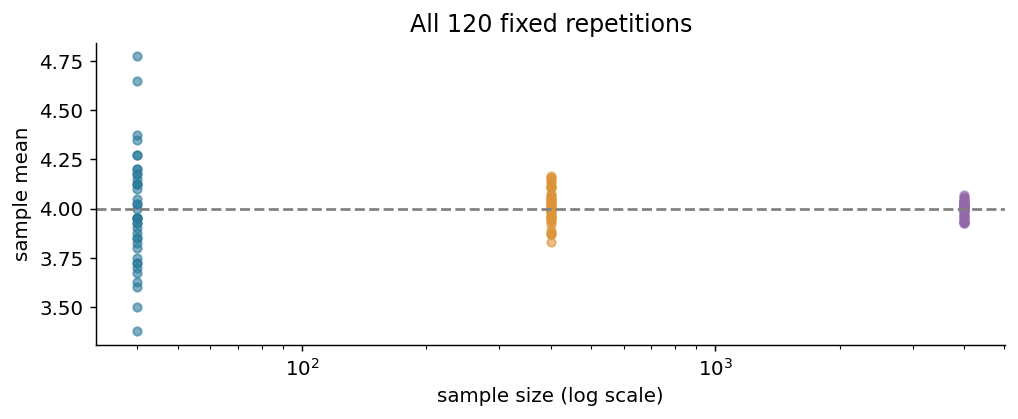

In [9]:
repetitions = []
for size in [40, 400, 4000]:
    for repeat in range(40):
        seed = e.REPEAT_SEED_BASE + size * 100 + repeat
        stats = e.moments(e.sample("poisson", size, seed, lam=4))
        repetitions.append({"size": size, "repeat": repeat, "seed": seed, **stats})
fig, ax = plt.subplots(figsize=(8, 3.5))
for size, color in zip([40,400,4000], ["#2b7a9b", "#dd9436", "#9468aa"]):
    means = [row["mean"] for row in repetitions if row["size"] == size]
    ax.scatter([size]*len(means), means, s=22, alpha=.6, color=color)
    print("size", size, "mean range", min(means), max(means))
ax.axhline(4, color="gray", ls="--")
ax.set(xscale="log", xlabel="sample size (log scale)", ylabel="sample mean", title="All 120 fixed repetitions")
show_figure(fig)

## Checks
### 8. 独立参考与显式边界
Fraction与Decimal独立参考检查总计1533项（含3项有限网格积分诊断）。边界检查62项拒绝加12项接受，合计74组。任何失败都应调查，不要提高容差让错误消失。

In [10]:
exact = e.exact_checks()
boundary = e.adversarial_checks()
print(json.dumps(exact, indent=2, ensure_ascii=False))
print({key: boundary[key] for key in ["rejections", "accepted", "total", "callback_calls_on_invalid_inputs"]})

{
  "checks": 1533,
  "max_binomial_abs_error": 2.7755575615628914e-16,
  "max_poisson_abs_error": 6.522560269672795e-16,
  "normal_quadrature": {
    "mass": 1.0,
    "mean": -5.551115123125783e-17,
    "second_moment": 1.0
  }
}
{'rejections': 62, 'accepted': 12, 'total': 74, 'callback_calls_on_invalid_inputs': 0}


### 9. 模型零质量与数值下溢
支持外点确实有0质量。支持内的极小正质量不能偷偷当作0；保留log概率是一个可行表达。这里math.erfc是标准库互补误差函数，定义为从a到无穷的exp(-t²)积分乘2/√π。对正态密度换元可得P(N(1,1)<0)=erfc(1/√2)/2。

In [11]:
print("Poisson(2), k=-1 support mass:", e.poisson_pmf(-1, 2))
print("Poisson(1000), k=0 log mass:", e.poisson_logpmf(0, 1000))
try:
    e.poisson_pmf(0, 1000)
except ValueError as error:
    print("Positive mass cannot be represented:", str(error))
else:
    raise ValueError("Underflow was not detected")
print("Normal(1,1) negative probability:", .5 * math.erfc(1 / math.sqrt(2)))

Poisson(2), k=-1 support mass: 0.0
Poisson(1000), k=0 log mass: -1000.0
Positive mass cannot be represented: positive probability underflows: use logpmf
Normal(1,1) negative probability: 0.15865525393145707


### 10. 核验指数族表达式
以下只对明确内部参数作代数核验，不用数值差分代替一般定理证明。有限支持上的A导数推导见正文；Gaussian自然参数的第二项必须负。

In [12]:
p = .25
eta = math.log(p / (1-p))
A = math.log1p(math.exp(eta))
reconstructed = [math.exp(eta*y-A) for y in [0,1]]
e.require(all(math.isclose(reconstructed[y], e.bernoulli_pmf(y,p), abs_tol=1e-14) for y in [0,1]), "Bernoulli exponential form")
mu, v, x = 1., 4., 2.
eta1, eta2 = mu/v, -1/(2*v)
A_normal = -eta1**2/(4*eta2) + .5*math.log(math.pi/(-eta2))
recovered = math.exp(eta1*x + eta2*x*x - A_normal)
e.require(math.isclose(recovered, e.normal_pdf(x,mu,v), rel_tol=1e-14), "Gaussian exponential form")
print("Bernoulli reconstructed:", reconstructed)
print("Gaussian eta1, eta2, density:", eta1, eta2, recovered)

Bernoulli reconstructed: [0.75, 0.24999999999999994]
Gaussian eta1, eta2, density: 0.25 -0.125 0.17603266338214973


## Next Steps
交付一页模型说明：一行代表什么、支持与单位、给定条件、参数、跨行假设、哪些证据会使模型可疑。解释为何类别编号平均数无固定语义、混合泊松方差超出均值、正态误差与正态原始值不同。

本Notebook已在独立新Python进程的真实ipykernel内顺序执行并保留4幅PNG输出；未测试浏览器UI、socket通信或读者Anaconda安装。数值模拟是有限证据，正文中的定理及其条件仍负责数学结论。来源和阅读范围见lecture.pdf与source-checks.json。